<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/PCA_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

np.random.seed(23)
my_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(my_vec1,cov_mat1,20)

df = pd.DataFrame(class1_sample , columns=['feature1','feature2','feature3'])
df['target'] = 1

my_vec2 =  np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(my_vec2,cov_mat2,20)

df1 = pd.DataFrame(class2_sample ,columns=['feature1','feature2','feature3'])
df1['target'] = 2

df = pd.concat([df, df1] , ignore_index=True)
df = df.sample(40)

In [3]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,2
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [4]:
import plotly.express as px
fig = px.scatter_3d(df , x=df['feature1'] , y=df['feature2'] , z=df['feature3'] , color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12 , line=dict(width=2 , color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [6]:
covariance_matrix = np.cov([df.iloc[:,0] , df.iloc[:,1] , df.iloc[:,2]])
print('Covariance Matrix:\n' , covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
eigen_value , eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:
eigen_value

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Populating the interactive namespace from numpy and matplotlib


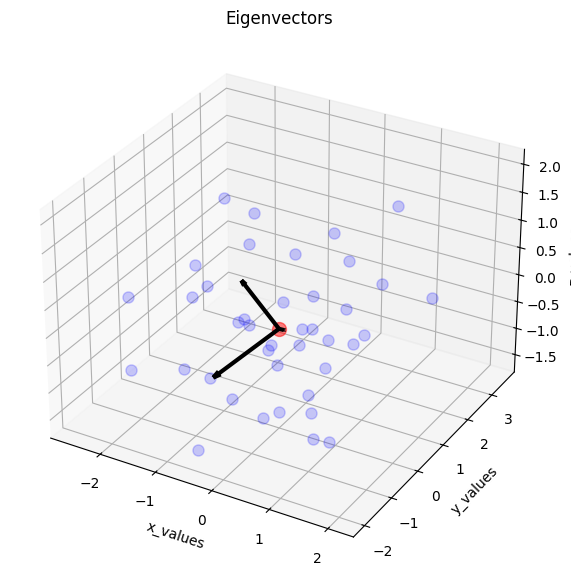

In [16]:
%pylab inline

from  matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch, ArrowStyle
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111 , projection='3d')

ax.plot(df['feature1'] ,df['feature2'], df['feature3'], 'o' , markersize=8 , color='blue' , alpha=0.2)

centroid = df[['feature1', 'feature2', 'feature3']].mean().values
ax.plot([centroid[0]],[centroid[1]],[centroid[2]],'o', markersize=10 ,color='red' , alpha=0.5)


for i, v in enumerate(eigen_vectors.T):

  ax.quiver(centroid[0], centroid[1], centroid[2],
            v[0], v[1], v[2],
            length=eigen_value[i],
            color='black',
            arrow_length_ratio=0.1,
            linewidth=3)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title("Eigenvectors")

plt.show()

In [21]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [26]:
transformed_df = np.dot(df.iloc[:,0:3], pc.T)

new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] =df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,2
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [28]:
pc.shape

(2, 3)

In [29]:
new_df['target'] = new_df['target'].astype('str')

fig = px.scatter(
    x=new_df['PC1'],
    y=new_df['PC2'],
    color=new_df['target'],
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(size=12),
    line=dict(width=2, color='DarkSlateGrey'),
    selector=dict(mode='markers')
)

fig.show()